In [1]:
from datetime import date, timedelta
from IPython.display import display

import polars as pl
import numpy as np

from mars.analysis.profiler import MarsDataProfiler
from mars.feature.binner import MarsNativeBinner, MarsOptimalBinner
from mars.analysis.evaluator import MarsBinEvaluator
from mars.utils.logger import set_log_level

pl.Config.set_fmt_str_lengths(100)
set_log_level("WARNING")

In [2]:
np.random.seed(2024)
N_MONTHS = 4       
N_SAMPLES = 20000     
BASE_DATE = date(2024, 1, 1)

data_parts = []

print(f"🛠️  正在生成 20 个特征的模拟数据 ({N_MONTHS} 个月 x {N_SAMPLES} 样本)...")

for i in range(N_MONTHS):
    curr_month = BASE_DATE + timedelta(days=31 * i)
    month_data = {
        "apply_date": [curr_month] * N_SAMPLES
    }
    
    # 初始 Logits 偏置
    # 设置为 -3.0，使基础坏账率保持在 4.7% 左右 (Sigmoid(-3) ≈ 0.047)
    total_logits = np.full(N_SAMPLES, -3.0) 
    
    # -------------------------------------------------
    # A组: [00-04] 稳定特征 (Stable)
    # -------------------------------------------------
    # 模拟信用评分、收入等级等强特征
    for k in range(5):
        feat_name = f"feat_stable_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 降低系数 (0.3 ~ 0.5)，避免单特征 IV 爆炸
        coef = np.random.choice([0.3, -0.3, 0.5, -0.4])
        total_logits += coef * raw_val
        
        # 少量缺失 (1%)
        val_with_nan = raw_val.copy()
        mask_nan = np.random.rand(N_SAMPLES) < 0.01
        val_with_nan[mask_nan] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # B组: [05-09] 漂移特征 (Drift)
    # -------------------------------------------------
    # 模拟某些政策变动导致的客群偏移
    for k in range(5):
        feat_name = f"feat_drift_{k:02d}"
        
        # 漂移幅度温和一点：半年偏移 0.5 个标准差
        drift_amount = i * 0.1 
        raw_val = np.random.normal(loc=drift_amount, scale=1, size=N_SAMPLES)
        
        # 弱相关 (0.1)，即使漂移也不会导致 badrate 剧烈波动
        total_logits += 0.1 * raw_val 
        
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < 0.05] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # C组: [10-14] 缺失恶化特征 (MissInc)
    # -------------------------------------------------
    # 模拟三方数据接口不稳定性
    for k in range(5):
        feat_name = f"feat_miss_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 这种特征通常还是有点用的
        total_logits += 0.2 * raw_val
        
        # 缺失率从 70% -> 95%
        miss_rate = 0.7 + (i * 0.05) 
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < miss_rate] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # D组: [15-19] 纯噪声特征 (Noise)
    # -------------------------------------------------
    for k in range(5):
        feat_name = f"feat_noise_{k:02d}"
        raw_val = np.random.normal(0, 2, N_SAMPLES)
        # 完全不加入 total_logits
        month_data[feat_name] = raw_val

    # -------------------------------------------------
    # 生成 Target
    # -------------------------------------------------
    # 增加随机噪声项，模拟模型无法解释的部分
    # scale=1.0 保证信噪比合理，坏账率不会非0即1
    total_logits += np.random.normal(0, 1.0, N_SAMPLES)
    
    probs = 1 / (1 + np.exp(-total_logits))
    target = (np.random.rand(N_SAMPLES) < probs).astype(int)
    
    month_data["target"] = target
    
    # 统计当月坏账率
    bad_rate = target.mean()
    print(f"  - Month {i+1}: Bad Rate = {bad_rate:.2%}")
    
    data_parts.append(pl.DataFrame(month_data))

# 合并
df_test: pl.DataFrame = pl.concat(data_parts)
df_test = df_test.with_columns(pl.col("apply_date").cast(pl.String))
df_test = df_test.to_pandas()

print("-" * 50)
print(f"✅ 数据生成完毕! Shape: {df_test.shape}")
print(f"   全局坏账率: {df_test['target'].mean():.2%}")
print("-" * 50)


🛠️  正在生成 20 个特征的模拟数据 (4 个月 x 20000 样本)...
  - Month 1: Bad Rate = 8.95%
  - Month 2: Bad Rate = 9.46%
  - Month 3: Bad Rate = 9.83%
  - Month 4: Bad Rate = 10.03%
--------------------------------------------------
✅ 数据生成完毕! Shape: (80000, 22)
   全局坏账率: 9.56%
--------------------------------------------------


In [3]:
df_test.head()

,apply_date,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,...,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,target
0,2024-01-01,1.668047,0.001636,-0.369792,-1.788306,0.456893,0.558442,0.572631,1.000406,1.312962,...,-0.387719,0.186176,NaN,0.619361,-2.046308,2.272591,2.792012,1.007653,-1.366040,1
1,2024-01-01,0.737348,0.431030,0.704325,-0.646752,-0.339895,1.272808,-1.481064,0.762491,0.156319,...,NaN,NaN,NaN,NaN,0.437779,0.419399,-2.198450,-0.033999,0.046231,0
2,2024-01-01,-0.201538,-0.269814,0.293191,-0.289382,-2.080532,-1.667490,-0.190527,0.252458,-1.884677,...,NaN,-0.605657,0.679121,NaN,2.524236,1.556764,2.372679,1.951594,2.254981,0
3,2024-01-01,-0.150912,0.107329,-1.788568,-0.313834,-1.395750,-0.911884,-0.805904,NaN,-0.496687,...,NaN,-0.591411,-0.085521,NaN,1.337186,-3.203901,-0.838905,0.146901,-3.287832,0
4,2024-01-01,0.916052,-0.013700,0.071821,0.168971,1.053674,-0.145678,NaN,0.295431,0.491123,...,0.686308,NaN,NaN,NaN,1.685961,3.220310,-1.081754,-2.042914,-0.734279,0


In [4]:
df_test.describe()

,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,feat_drift_04,...,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,target
count,79181.000000,79215.000000,79219.000000,79204.000000,79190.000000,76061.000000,75996.000000,76032.000000,76020.000000,76016.000000,...,17940.000000,18031.000000,18086.000000,17820.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,-0.001474,-0.002082,-0.005016,-0.006769,-0.005122,0.141872,0.152438,0.149499,0.148990,0.152301,...,-0.003590,0.001653,0.000487,0.009240,-0.003918,0.007205,0.009650,0.004013,0.002120,0.095650
std,1.001218,1.000772,1.000489,0.998847,1.003525,1.008353,1.008830,1.006020,1.004284,1.003099,...,1.000013,0.995759,0.999642,1.003729,1.998651,2.001277,1.992375,1.996148,1.989634,0.294112
min,-4.659177,-4.390396,-4.407705,-4.102802,-3.951435,-3.914277,-4.287416,-4.170083,-4.036734,-4.782146,...,-4.103873,-4.358812,-3.635214,-4.252540,-8.283695,-8.520235,-8.598979,-8.501689,-8.396221,0.000000
25%,-0.678026,-0.672495,-0.677107,-0.680099,-0.683605,-0.540526,-0.526680,-0.529035,-0.522321,-0.525583,...,-0.675484,-0.674118,-0.672622,-0.665557,-1.357865,-1.338772,-1.347864,-1.349957,-1.344766,0.000000
50%,0.000495,-0.005935,-0.011218,-0.006040,-0.010858,0.138559,0.146444,0.150636,0.150328,0.154468,...,-0.003343,0.008847,0.002267,0.010923,0.000915,0.010633,0.017456,0.011389,0.005896,0.000000
75%,0.676190,0.668559,0.668609,0.666787,0.672839,0.827779,0.831296,0.828631,0.823826,0.831417,...,0.661835,0.672691,0.670416,0.690417,1.345920,1.358799,1.348486,1.351259,1.346242,0.000000
max,4.402141,4.274114,5.088348,3.970648,4.664161,4.499981,4.465295,4.508330,4.350508,4.745254,...,4.216725,3.936684,4.200971,4.314615,7.977524,8.411534,8.165473,8.714990,9.245517,1.000000


In [5]:
features = [col for col in df_test.columns if col.startswith("feat_")]
len(features)

20

In [6]:
features = [col for col in df_test.columns if col.startswith("feat_")]
test_profiler = MarsDataProfiler(
    df=df_test,
    features=features,
    exclude_features = None,
    include_dtypes = None,
    custom_missing_values = None,
    custom_special_values = None,
    overview_batch_size = 500,
    psi_batch_size = 50,
    psi_n_bins = 10,
    psi_bin_method = "quantile",
    psi_cv_ignore_threshold = 0.05,
    sample_frac = None,
    config = None
)

In [7]:
test_profiler_report = test_profiler.generate_profile(
    profile_by="month",
    dt_col="apply_date",
    config_overrides={
        "dq_metrics": ["missing", "zeros", "top1"],
        "stat_metrics": ["mean", "std", "min", "max",]
    }
)
test_profiler_report

In [8]:
test_profiler_report.show_overview()

feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
feat_drift_00,Float64,▂▂▄█▇▃▂▂,4.92%,0.00%,4.92%,None,0.14,1.01,-3.91,4.50
feat_drift_01,Float64,▂▂▃▇█▄▂▂,5.00%,0.00%,5.00%,None,0.15,1.01,-4.29,4.47
feat_drift_02,Float64,▂▂▄█▇▄▂▂,4.96%,0.00%,4.96%,None,0.15,1.01,-4.17,4.51
feat_drift_03,Float64,▂▂▄█▇▄▂▂,4.98%,0.00%,4.98%,None,0.15,1.00,-4.04,4.35
feat_drift_04,Float64,▂▂▃▆█▄▂▂,4.98%,0.00%,4.98%,None,0.15,1.00,-4.78,4.75
feat_miss_00,Float64,▂▂▅█▆▃▂▂,77.47%,0.00%,77.47%,None,-0.00,0.99,-3.61,4.13
feat_miss_01,Float64,▂▂▄█▇▄▂▂,77.58%,0.00%,77.58%,None,-0.00,1.00,-4.10,4.22
feat_miss_02,Float64,▂▂▃▆█▄▂▂,77.46%,0.00%,77.46%,None,0.00,1.00,-4.36,3.94
feat_miss_03,Float64,▂▂▅█▆▃▂▂,77.39%,0.00%,77.39%,None,0.00,1.00,-3.64,4.20
feat_miss_04,Float64,▂▂▄█▇▄▂▂,77.72%,0.00%,77.72%,None,0.01,1.00,-4.25,4.31


In [9]:
test_profiler_report.show_trend("missing", ascending=False)

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,total
feat_drift_00,Float64,4.84%,4.78%,5.13%,4.93%,4.92%
feat_drift_01,Float64,5.15%,4.92%,5.01%,4.94%,5.00%
feat_drift_02,Float64,5.16%,5.02%,4.98%,4.67%,4.96%
feat_drift_03,Float64,5.07%,5.22%,4.70%,4.91%,4.98%
feat_drift_04,Float64,5.03%,4.92%,4.95%,5.02%,4.98%
feat_miss_00,Float64,84.80%,80.03%,75.11%,69.95%,77.47%
feat_miss_01,Float64,85.30%,80.12%,74.83%,70.05%,77.58%
feat_miss_02,Float64,84.76%,79.93%,74.74%,70.41%,77.46%
feat_miss_03,Float64,85.06%,80.09%,74.31%,70.10%,77.39%
feat_miss_04,Float64,85.08%,80.54%,75.27%,70.00%,77.72%


In [10]:
test_profiler_report.show_trend("mean")

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total,group_mean,group_var,group_cv
feat_drift_00,Float64,-0.02,0.09,0.20,0.30,0.14,0.14,0.0180,0.9461
feat_drift_01,Float64,0.00,0.09,0.21,0.31,0.15,0.15,0.0181,0.8828
feat_drift_02,Float64,-0.01,0.10,0.21,0.30,0.15,0.15,0.0179,0.8936
feat_drift_03,Float64,-0.01,0.11,0.19,0.30,0.15,0.15,0.0175,0.8880
feat_drift_04,Float64,0.01,0.10,0.20,0.30,0.15,0.15,0.0156,0.8212
feat_miss_00,Float64,-0.01,0.01,0.00,0.01,-0.00,0.00,0.0001,13.1305
feat_miss_01,Float64,-0.01,-0.00,0.02,-0.03,-0.00,-0.00,0.0004,4.1241
feat_miss_02,Float64,-0.01,0.02,0.00,-0.00,0.00,0.00,0.0002,7.2905
feat_miss_03,Float64,-0.00,0.01,-0.00,0.00,0.00,0.00,0.0000,13.0104
feat_miss_04,Float64,0.01,-0.00,0.01,0.02,0.01,0.01,0.0001,0.8963


In [11]:
overview, dq_table, stat_table = test_profiler_report.get_profile_data()
display(overview.head(), dq_table["missing"].head())

,feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
0,feat_drift_00,Float64,▂▂▄█▇▃▂▂,0.049237,0.0,0.049237,None,0.141872,1.008353,-3.914277,4.499981
1,feat_drift_01,Float64,▂▂▃▇█▄▂▂,0.050050,0.0,0.050050,None,0.152438,1.008830,-4.287416,4.465295
2,feat_drift_02,Float64,▂▂▄█▇▄▂▂,0.049600,0.0,0.049600,None,0.149499,1.006020,-4.170083,4.508330
3,feat_drift_03,Float64,▂▂▄█▇▄▂▂,0.049750,0.0,0.049750,None,0.148990,1.004284,-4.036734,4.350508
4,feat_drift_04,Float64,▂▂▃▆█▄▂▂,0.049800,0.0,0.049800,None,0.152301,1.003099,-4.782146,4.745254


,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total
0,feat_drift_00,Float64,0.04935,0.05135,0.04780,0.04845,0.049237
1,feat_drift_01,Float64,0.04940,0.05010,0.04925,0.05145,0.050050
2,feat_drift_02,Float64,0.04675,0.04985,0.05020,0.05160,0.049600
3,feat_drift_03,Float64,0.04910,0.04695,0.05225,0.05070,0.049750
4,feat_drift_04,Float64,0.05020,0.04945,0.04925,0.05030,0.049800


In [12]:
# (
#     overview
#     .filter(pl.col("missing_rate") < 0.8)
#     .select("feature")
#     .to_series()
#     .to_list()
# )

In [13]:
test_native_binner = MarsNativeBinner(
    features=features,
    method = "quantile",
    n_bins = 9,
    special_values = None,
    missing_values = None,
    min_samples = 0.05, # 仅对 cart 有效
    cart_params = None,
    remove_empty_bins = False, # 仅对 uniform 有效
    n_jobs = -1
)
test_native_binner.fit(df_test, df_test["target"])

,features,"['feat_stable_00', 'feat_stable_01', ...]"
,method,'quantile'
,n_bins,9
,special_values,[]
,missing_values,[]
,min_samples,0.05
,cart_params,None
,remove_empty_bins,False
,n_jobs,23


In [14]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,null,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,5,8,1,-1
1,0.737348,1.272808,NaN,0.437779,7,6,5,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,3,8,1


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,null,-2.046308,0.025269,-0.16974,0.069261,0.008144
0.737348,1.272808,null,0.437779,0.141669,-0.089145,0.01135,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [15]:
test_native_bin_performance_table = test_native_binner.profile_bin_performance(df_test[features], df_test["target"], update_woe=True)
test_native_bin_performance_table

feature,bin_label,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,u32,i32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_stable_03_bin""","""00_[-inf, -1.23)""",8800,815,7985,0.11,0.092614,0.106508,0.110369,-0.035611,0.000138,0.519341,0.55327,0.033929,0.007241,0.034238,0.522656,0.968255
"""feat_stable_03_bin""","""01_[-1.23, -0.769)""",8801,782,8019,0.110013,0.088854,0.102196,0.110839,-0.081194,0.000702,0.203607,0.221761,0.018155,0.007241,0.034238,0.522656,0.928944
"""feat_stable_03_bin""","""02_[-0.769, -0.437)""",8800,803,7997,0.11,0.09125,0.10494,0.110535,-0.051946,0.000291,0.412833,0.442901,0.030068,0.007241,0.034238,0.522656,0.953999
"""feat_stable_03_bin""","""03_[-0.437, -0.143)""",8800,798,8002,0.11,0.090682,0.104286,0.110604,-0.058817,0.000372,0.307893,0.332366,0.024472,0.007241,0.034238,0.522656,0.948059
"""feat_stable_03_bin""","""04_[-0.143, 0.132)""",8801,776,8025,0.110013,0.088172,0.101411,0.110922,-0.089644,0.000853,0.101411,0.110922,0.009511,0.007241,0.034238,0.522656,0.921817
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_miss_01_bin""","""05_[0.133, 0.421)""",1993,192,1801,0.024913,0.096337,0.025091,0.024894,0.007919,0.000002,0.904862,0.927393,0.022531,0.012402,0.022729,0.520354,1.007184
"""feat_miss_01_bin""","""06_[0.421, 0.75)""",1994,226,1768,0.024925,0.11334,0.029535,0.024437,0.189452,0.000966,0.9638,0.976267,0.012467,0.012402,0.022729,0.520354,1.184945
"""feat_miss_01_bin""","""07_[0.75, 1.23)""",1993,225,1768,0.024913,0.112895,0.029404,0.024437,0.185017,0.000919,0.934266,0.95183,0.017564,0.012402,0.022729,0.520354,1.180294


In [16]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,null,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,5,8,1,-1
1,0.737348,1.272808,NaN,0.437779,7,6,5,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,3,8,1


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
0,1.668047,0.558442,NaN,-2.046308,0.025269,-0.169740,0.069261,0.008144
1,0.737348,1.272808,NaN,0.437779,0.141669,-0.089145,0.011350,0.008144
2,-0.201538,-1.667490,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [17]:
test_opt_biner = MarsOptimalBinner(
    features=features,
    cat_features = None,
    n_bins = 10,
    min_n_bins = 1,
    min_bin_size = 0.02,
    n_prebins = 20,
    prebinning_method = "cart",
    min_prebin_size = 0.01,
    monotonic_trend = "auto_asc_desc",
    solver = "cp",
    time_limit = 2,
    special_values = None,
    missing_values = None,
    cart_params = {"random_state": 2025},
    n_jobs = -1
)
test_opt_biner.fit(df_test, df_test["target"])

,features,"['feat_stable_00', 'feat_stable_01', ...]"
,cat_features,[]
,n_bins,10
,min_n_bins,1
,min_bin_size,0.02
,min_bin_n_event,3
,n_prebins,20
,prebinning_method,'cart'
,min_prebin_size,0.01
,monotonic_trend,'auto_asc_desc'
,solver,'cp'


In [18]:
test_opt_biner.fit_failures_

{}

In [19]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_opt_biner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""03_[0.0774, 0.808)""","""05_[1.14, inf)""","""00_[-inf, 0.603)""","""Missing"""
0.737348,1.272808,null,0.437779,"""06_[1.27, 1.8)""","""04_[0.0983, 1.14)""","""00_[-inf, 0.603)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.58)""","""02_[-0.947, -0.111)""","""02_[1.16, 3.74)""","""01_[-1.16, -0.49)"""


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,3,5,0,-1
1,0.737348,1.272808,NaN,0.437779,6,4,0,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,2,2,1


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,null,-2.046308,0.030675,-0.189565,0.026851,0.008144
0.737348,1.272808,null,0.437779,0.158384,-0.080264,0.026851,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.237073,0.03528,-0.049829,-0.200117


In [20]:
test_opt_bin_performance_table = test_opt_biner.profile_bin_performance(df_test[features], df_test["target"])
test_opt_bin_performance_table

feature,bin_label,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,u32,i32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_stable_03_bin""","""00_[-inf, 0.104)""",43137,3882,39255,0.539213,0.089992,0.507318,0.542586,-0.067208,0.00237,0.507318,0.542586,0.035267,0.009474,0.035576,0.52306,0.94085
"""feat_stable_03_bin""","""01_[0.104, 0.985)""",23385,2247,21138,0.292313,0.096087,0.293649,0.292171,0.005044,0.000007,0.810638,0.844737,0.034099,0.009474,0.035576,0.52306,1.004571
"""feat_stable_03_bin""","""02_[0.985, 1.35)""",5797,635,5162,0.072462,0.109539,0.082985,0.07135,0.151066,0.001758,0.893623,0.916086,0.022464,0.009474,0.035576,0.52306,1.145211
"""feat_stable_03_bin""","""03_[1.35, inf)""",6885,814,6071,0.086062,0.118228,0.106377,0.083914,0.237203,0.005328,1.0,1.0,0.0,0.009474,0.035576,0.52306,1.236048
"""feat_stable_03_bin""","""Missing""",796,74,722,0.00995,0.092965,0.009671,0.00998,-0.031439,0.00001,0.516989,0.552565,0.035576,0.009474,0.035576,0.52306,0.971927
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_miss_01_bin""","""03_[-0.262, 0.123)""",2706,239,2467,0.033825,0.088322,0.031234,0.034099,-0.087774,0.000252,0.103894,0.125587,0.021693,0.013425,0.023144,0.520805,0.92339
"""feat_miss_01_bin""","""04_[0.123, 0.466)""",2353,226,2127,0.029413,0.096048,0.029535,0.0294,0.004588,6.2027e-7,0.907867,0.930876,0.023008,0.013425,0.023144,0.520805,1.004157
"""feat_miss_01_bin""","""05_[0.466, 1.26)""",3816,436,3380,0.0477,0.114256,0.056979,0.046719,0.198532,0.002037,0.964846,0.977594,0.012749,0.013425,0.023144,0.520805,1.194519


[MARS] 2026-01-30 00:15:29 - WARNING - ⚠️ 1 features were not binned and will be skipped in evaluation. Examples: ['apply_date_bin']



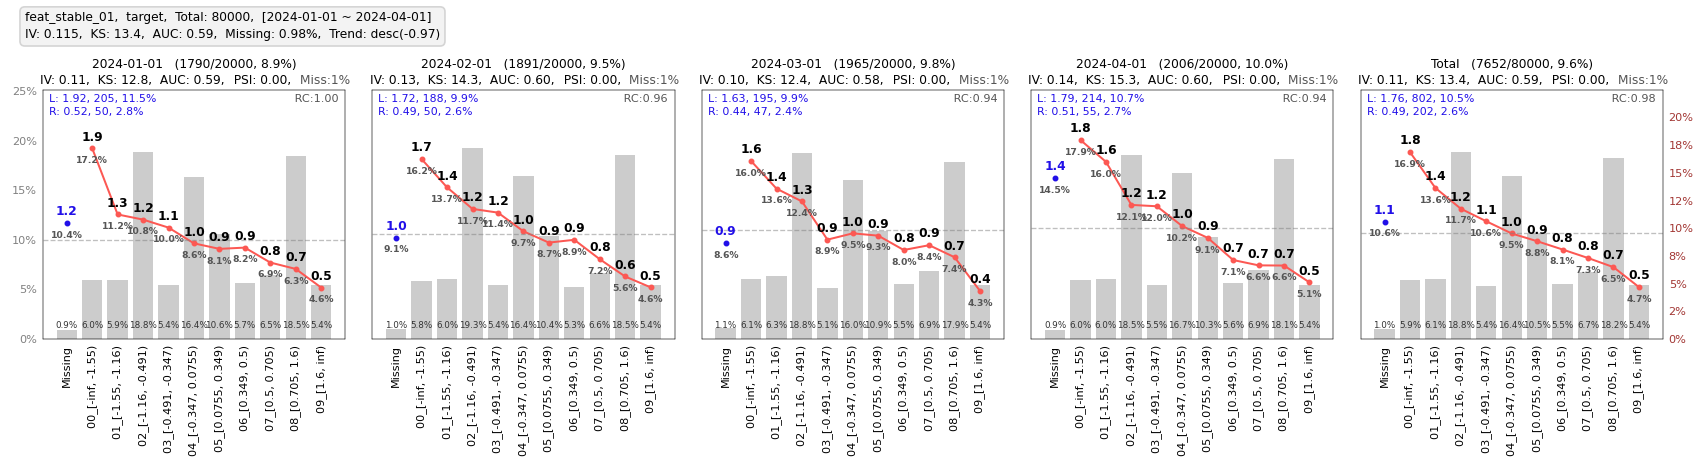


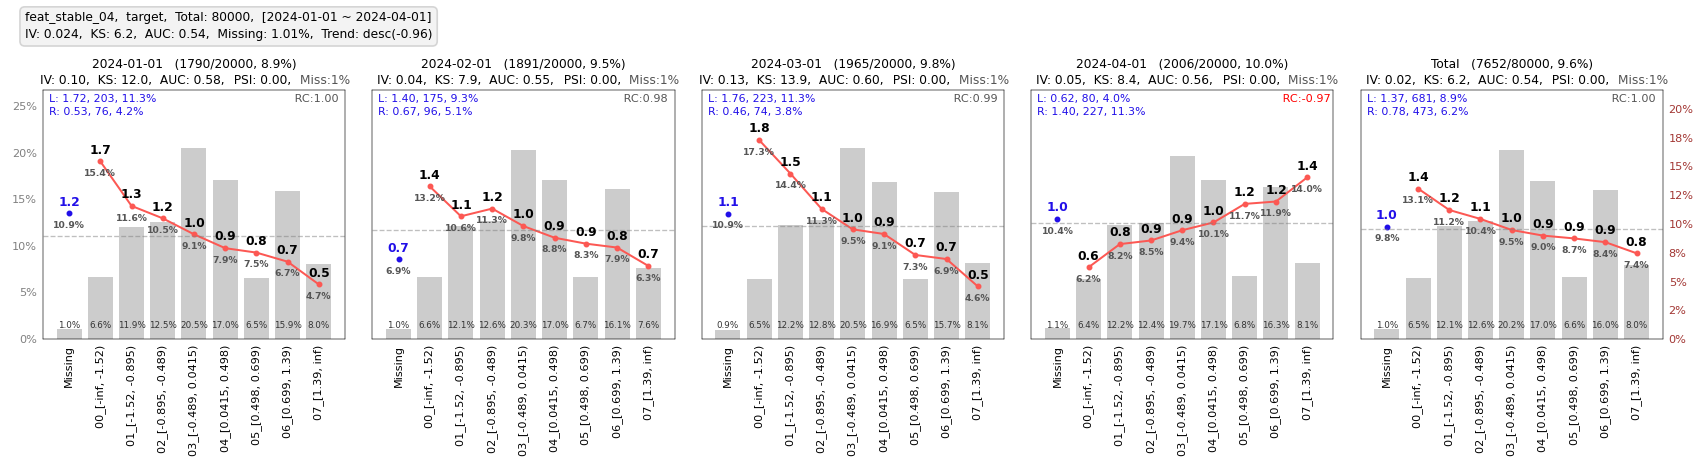


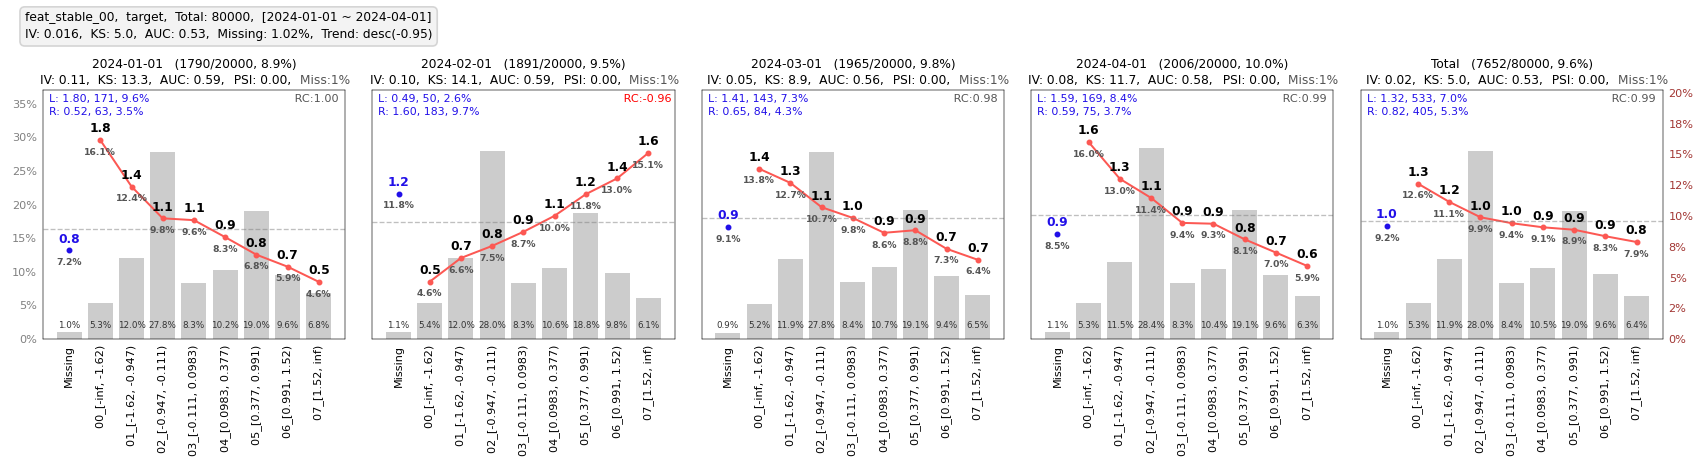


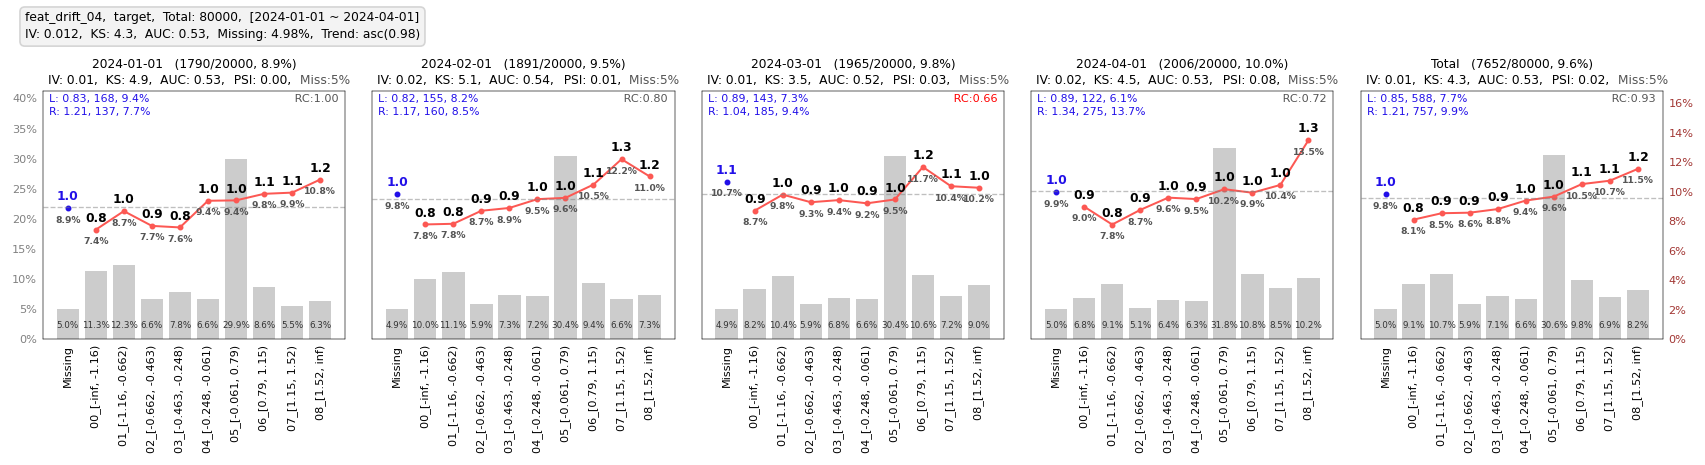


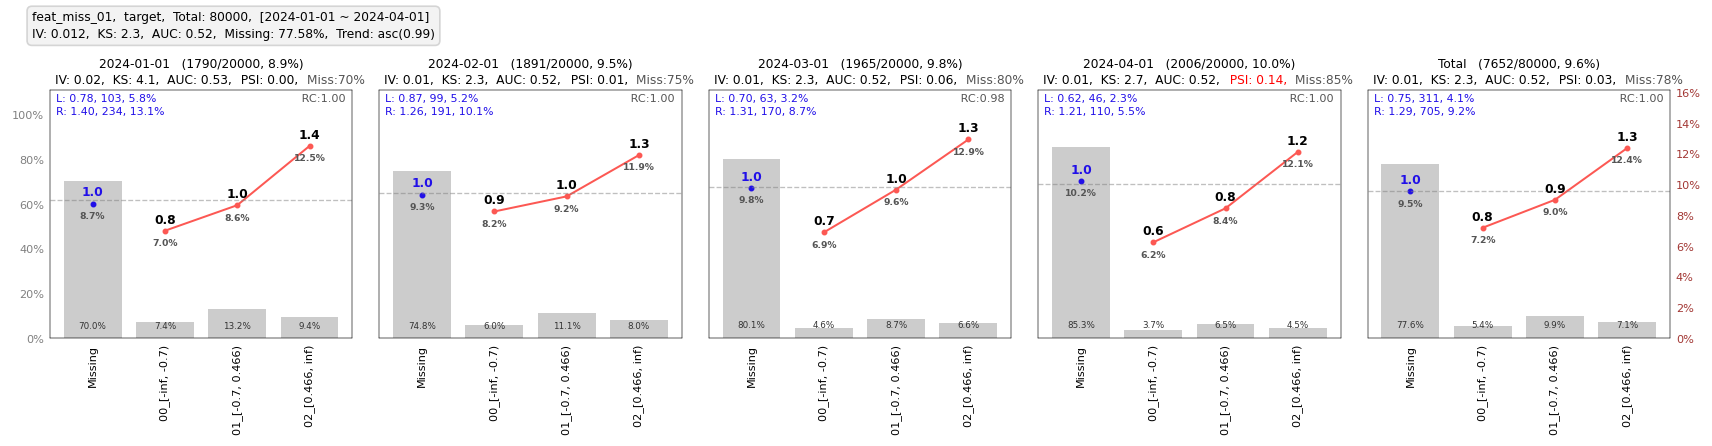


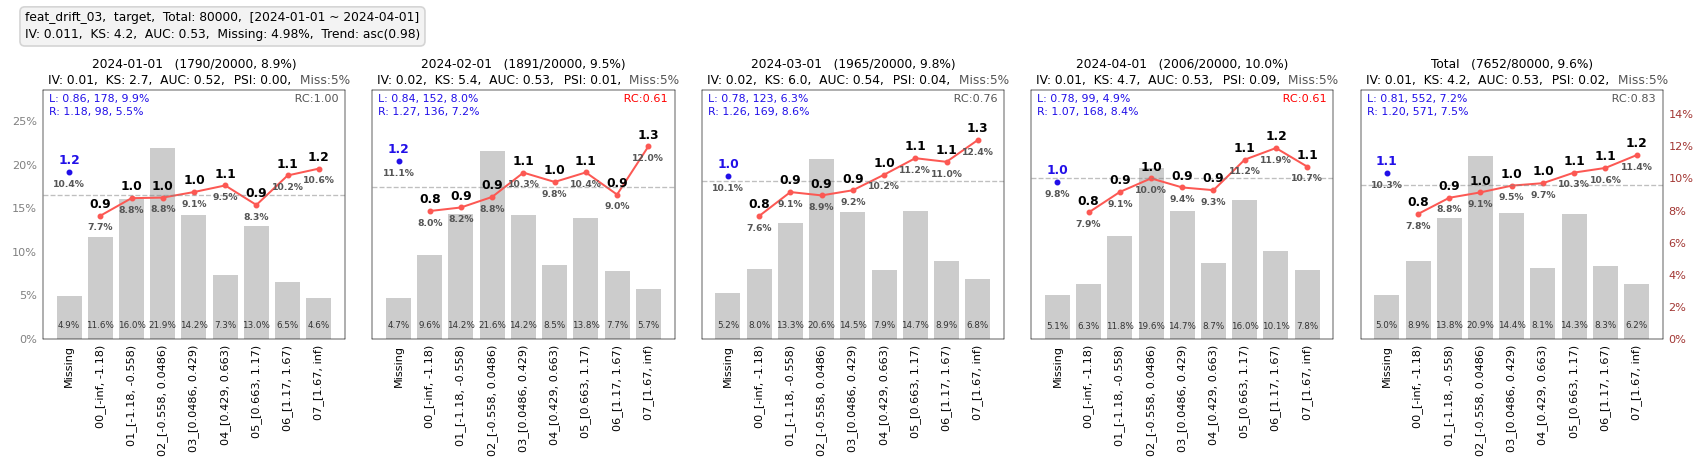


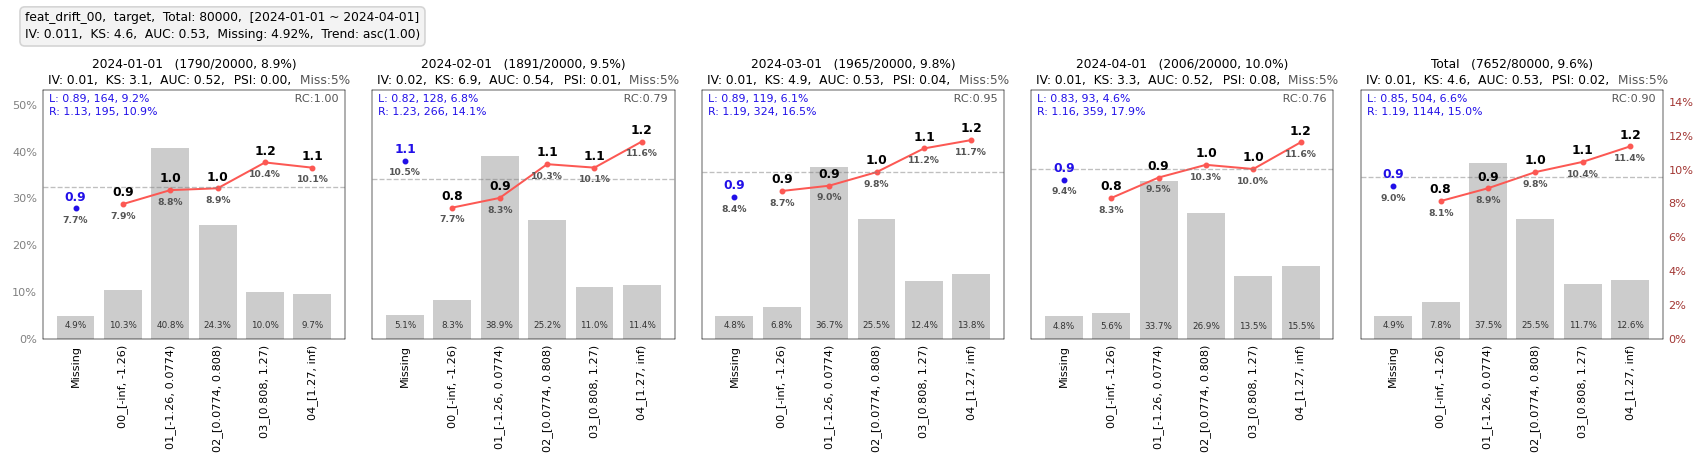


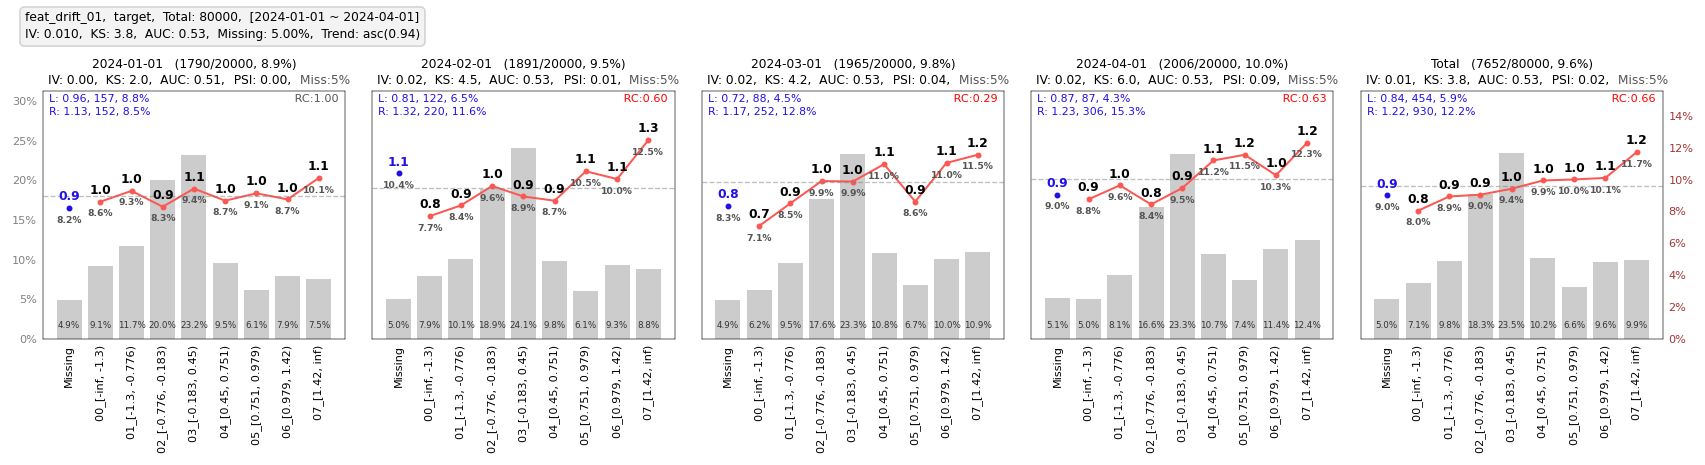


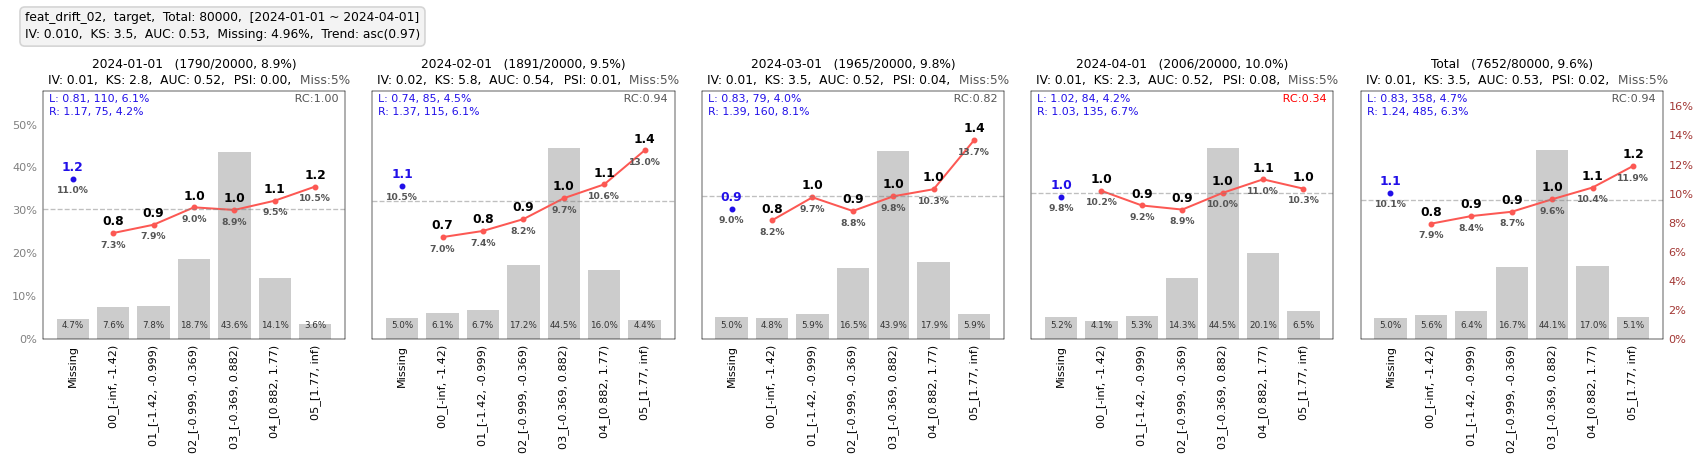


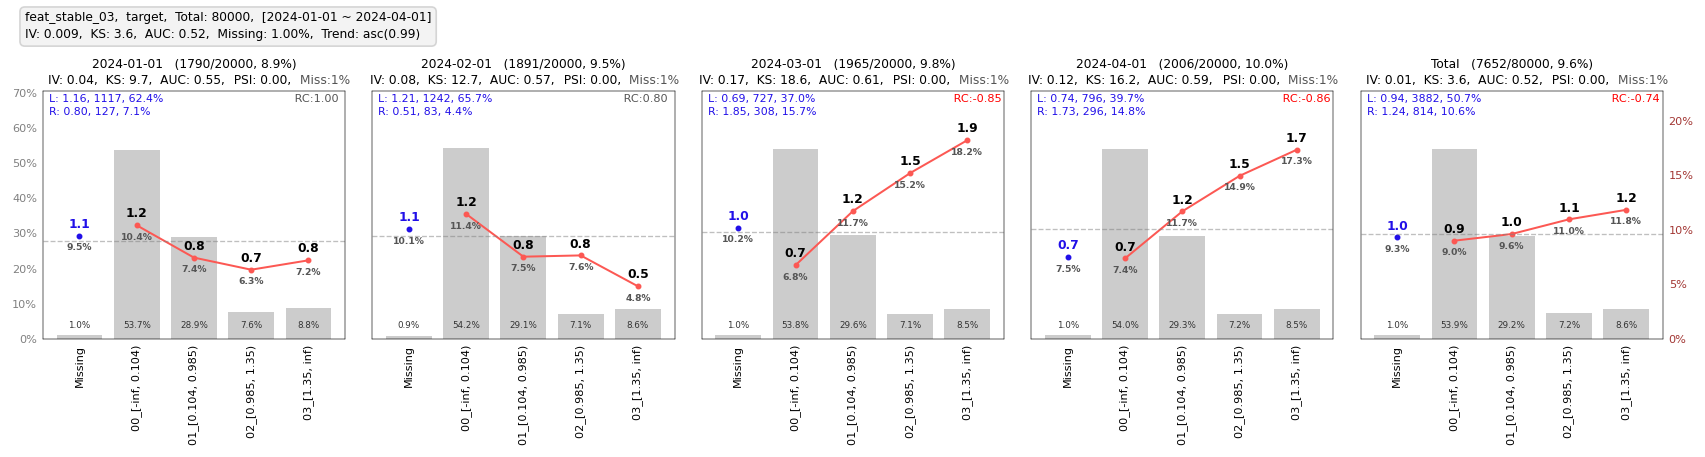

In [ ]:
test_evaluator = MarsBinEvaluator(target_col="target")
data = test_evaluator.evaluate_and_plot(
    df_test,
    # profile_by="month",
    dt_col="apply_date",
    bining_type="opt",               
    n_bins=10,                        # 最大分箱数
    min_bin_size=0.05,               # 最小箱占比 5% 
    min_bin_n_event=5,               #  每箱至少 5 个坏人
    prebinning_method="cart",        # 预分箱方法
    n_prebins=50,                           # 预分箱数
    min_prebin_size=0.01,            # 预分箱最小占比 1%
    monotonic_trend="auto_asc_desc", 
)

In [22]:
data

In [ ]:
test_evaluator = MarsBinEvaluator(binner=test_opt_biner, target_col="target")

test_evaluator_report = test_evaluator.evaluate(
    df=df_test,
    features=features,
    profile_by="month",
    dt_col="apply_date"
)

In [ ]:
test_evaluator_report

In [ ]:
display(test_evaluator_report.show_trend("psi", ascending=False))

In [ ]:
display(test_evaluator_report.show_trend("iv", ascending=True))

In [ ]:
display(test_evaluator_report.show_trend("risk_corr", ascending=False))

In [ ]:
summary_df, trend_tables, detail_table = test_evaluator_report.get_evaluation_data()
trend_tables.keys(), type(trend_tables["auc"])

In [ ]:
detail_table

In [ ]:
test_evaluator_report.write_excel()

In [ ]:
set_log_level("INFO")
test_evaluator.plot_feature_binning_risk_trends(
    test_evaluator_report,
    features=features,
    sort_by="iv",
    dpi=150
)

In [ ]:
data

In [ ]:
data.get_evaluation_data()["detail_table"]